# Social Network Ads — Purchase Prediction

This project uses Logistic Regression to predict whether a social-network user will purchase a product after seeing an advertisement.

## Goal

Predict the `Purchased` value:

- `0` — user did not purchase
- `1` — user purchased

## Features

The model uses:

- `Gender`
- `Age`
- `EstimatedSalary`

## Model

The data is split into training and test sets. Features are scaled with `StandardScaler`, then a Logistic Regression model is trained to predict purchase decisions.

```python
prediction = model.predict(new_user_scaled)

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [112]:
df = pd.read_csv('Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


### First we apply a simple logistic regression and then evaluate the results
#### Then we go further and apply more complex technique to decrease the loss

In [35]:
df = df.drop('User ID', axis=1)

In [36]:
df = pd.get_dummies(df, drop_first=True).astype(int)
df.sample(5)

,Age,EstimatedSalary,Purchased,Gender_Male
281,35,61000,0,1
17,45,26000,1,1
288,41,79000,0,1
107,27,89000,0,1
31,27,137000,1,0


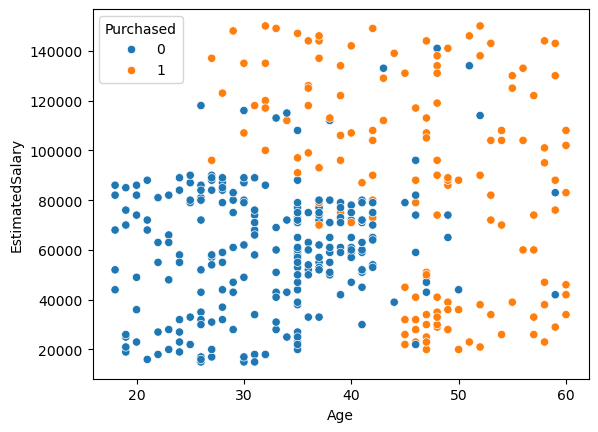

In [37]:
sns.scatterplot(df, x='Age', y='EstimatedSalary', hue='Purchased');

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
 3   Gender_Male      400 non-null    int64
dtypes: int64(4)
memory usage: 12.6 KB


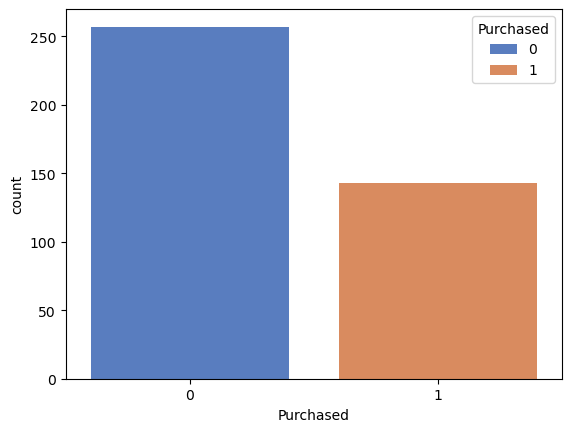

In [40]:
sns.countplot(df, x='Purchased', palette='muted', hue='Purchased');

In [42]:
X = df.drop(['Purchased', 'Gender_Male'], axis=1)
y = df['Purchased']

In [43]:
from sklearn.preprocessing import StandardScaler

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [46]:
scaler = StandardScaler()

In [47]:
scaled_x_train = scaler.fit_transform(X_train)
scaled_x_test = scaler.transform(X_test)

In [48]:
from sklearn.linear_model import LogisticRegression

In [49]:
model = LogisticRegression()

In [50]:
model.fit(scaled_x_train,  y_train)

LogisticRegression()

In [51]:
preds = model.predict(scaled_x_test)

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix 

In [53]:
confusion_matrix(y_test,preds)

array([[72,  8],
       [13, 27]])

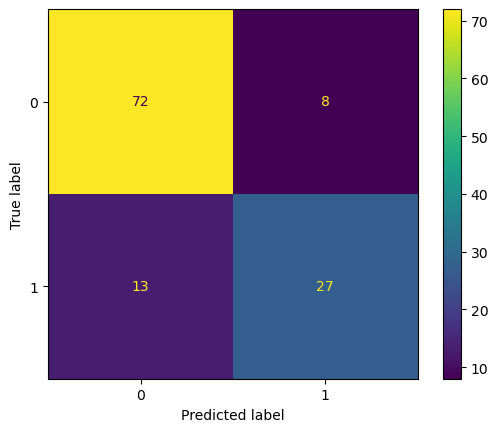

In [54]:
ConfusionMatrixDisplay.from_estimator(model, scaled_x_test, y_test);

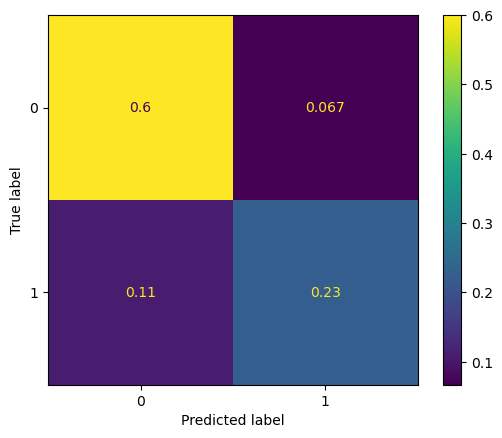

In [55]:
ConfusionMatrixDisplay.from_estimator(model, scaled_x_test, y_test, normalize='all');

In [56]:
df.sample(3)

,Age,EstimatedSalary,Purchased,Gender_Male
194,28,89000,0,1
130,31,58000,0,1
208,40,142000,1,0


In [31]:
df.columns

Index(['Age', 'EstimatedSalary', 'Purchased', 'Gender_Male',
       'User ID_15569641', 'User ID_15570769', 'User ID_15570932',
       'User ID_15571059', 'User ID_15573452', 'User ID_15573926',
       ...
       'User ID_15810075', 'User ID_15810800', 'User ID_15810944',
       'User ID_15811177', 'User ID_15811613', 'User ID_15813113',
       'User ID_15814004', 'User ID_15814553', 'User ID_15814816',
       'User ID_15815236'],
      dtype='object', length=403)

In [26]:
df = pd.get_dummies(df, drop_first=True).astype(int)

In [27]:
df.head()

,Age,EstimatedSalary,Purchased,Gender_Male,User ID_15569641,User ID_15570769,User ID_15570932,User ID_15571059,User ID_15573452,User ID_15573926,...,User ID_15810075,User ID_15810800,User ID_15810944,User ID_15811177,User ID_15811613,User ID_15813113,User ID_15814004,User ID_15814553,User ID_15814816,User ID_15815236
0,19,19000,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,35,20000,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,26,43000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,27,57000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,19,76000,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [57]:
X = df.drop(['Purchased'], axis=1)
y = df['Purchased']

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [60]:
from sklearn.preprocessing import StandardScaler

In [61]:
scaler = StandardScaler()

In [62]:
scaled_x_train = scaler.fit_transform(X_train)
scaled_x_test = scaler.transform(X_test)

In [63]:
from sklearn.linear_model import LogisticRegression

In [64]:
model = LogisticRegression()

In [65]:
model.fit(scaled_x_train,y_train)

LogisticRegression()

In [66]:
preds = model.predict(scaled_x_test)

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

In [68]:
accuracy_score(y_test, preds)

0.8333333333333334

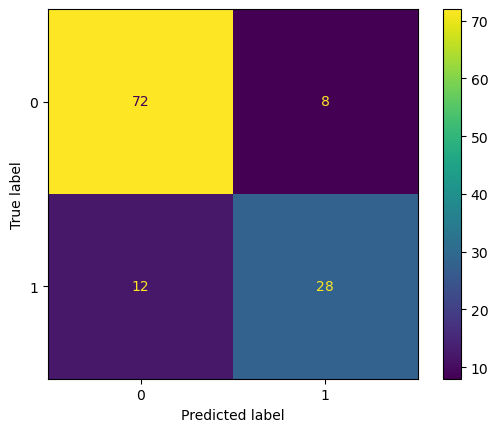

In [69]:
ConfusionMatrixDisplay.from_estimator(model, scaled_x_test,y_test);

In [70]:
from sklearn.metrics import confusion_matrix

In [71]:
confusion_matrix(y_test,preds)

array([[72,  8],
       [12, 28]])

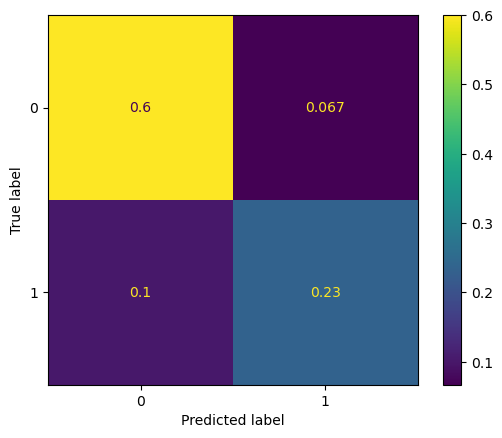

In [72]:
ConfusionMatrixDisplay.from_estimator(model, scaled_x_test,y_test, normalize='all');

In [73]:
from sklearn.metrics import PrecisionRecallDisplay

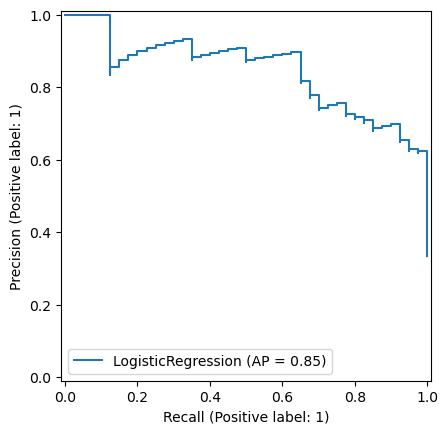

In [74]:
PrecisionRecallDisplay.from_estimator(model,scaled_x_test, y_test);

In [75]:
train_pred = model.predict(scaled_x_train)

In [76]:
confusion_matrix(y_train, train_pred)

array([[163,  14],
       [ 29,  74]])

In [77]:
df = pd.read_csv('Social_Network_Ads.csv')
df.sample(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
77,15774179,Female,22,27000,0
256,15609637,Female,41,72000,0
217,15582066,Male,40,78000,0
317,15684861,Male,35,55000,0
87,15631912,Female,28,85000,0


In [78]:
df = df.drop('User ID', axis=1)

In [79]:
df = pd.get_dummies(df, drop_first=False).astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
 3   Gender_Female    400 non-null    int64
 4   Gender_Male      400 non-null    int64
dtypes: int64(5)
memory usage: 15.8 KB


In [80]:
df.sample(4)

,Age,EstimatedSalary,Purchased,Gender_Female,Gender_Male
303,37,79000,1,0,1
304,40,60000,0,1,0
159,32,135000,1,1,0
215,60,108000,1,1,0


In [82]:
X = df.drop('Purchased', axis=1)
y = df['Purchased']

In [83]:
from sklearn.model_selection import train_test_split

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [85]:
from sklearn.preprocessing import StandardScaler

In [86]:
scaler = StandardScaler()

In [87]:
scaled_x_train = scaler.fit_transform(X_train)
scaled_x_test = scaler.transform(X_test)

In [88]:
from sklearn.linear_model import LogisticRegression

In [89]:
l_model = LogisticRegression(solver='saga',
                            multi_class='ovr',
                            max_iter=5000)

In [90]:
penalty = ['l1', 'l2', 'elasticnet']
l1_ratio = np.linspace(0,1,20)
C = np.logspace(0,10,20)

param_grid = {'penalty':penalty,
             'l1_ratio':l1_ratio,
             'C':C}

In [91]:
from sklearn.model_selection import GridSearchCV

In [92]:
grid_model = GridSearchCV(l_model, param_grid=param_grid)

In [93]:
import warnings
warnings.filterwarnings("ignore")
grid_model.fit(scaled_x_train,y_train)

GridSearchCV(estimator=LogisticRegression(max_iter=5000, multi_class='ovr',
                                          solver='saga'),
             param_grid={'C': array([1.00000000e+00, 3.35981829e+00, 1.12883789e+01, 3.79269019e+01,
       1.27427499e+02, 4.28133240e+02, 1.43844989e+03, 4.83293024e+03,
       1.62377674e+04, 5.45559478e+04, 1.83298071e+05, 6.15848211e+05,
       2.06913808e+06, 6.95192796e+06, 2.33572147e+07, 7.84759970e+07,
       2.63665090e+08, 8.85866790e+08, 2.97635144e+09, 1.00000000e+10]),
                         'l1_ratio': array([0.        , 0.05263158, 0.10526316, 0.15789474, 0.21052632,
       0.26315789, 0.31578947, 0.36842105, 0.42105263, 0.47368421,
       0.52631579, 0.57894737, 0.63157895, 0.68421053, 0.73684211,
       0.78947368, 0.84210526, 0.89473684, 0.94736842, 1.        ]),
                         'penalty': ['l1', 'l2', 'elasticnet']})

In [94]:
grid_model.best_params_

{'C': 1.0, 'l1_ratio': 0.0, 'penalty': 'l1'}

In [105]:
final_model = grid_model.best_estimator_

In [106]:
y_pred = final_model.predict(scaled_x_test)

In [107]:
y_pred

array([0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1])

In [108]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix,accuracy_score

In [109]:
confusion_matrix(y_test, y_pred)

array([[72,  8],
       [13, 27]])

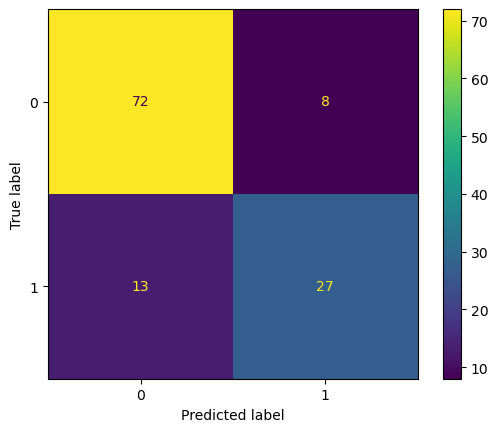

In [110]:
ConfusionMatrixDisplay.from_estimator(grid_model, scaled_x_test, y_test);

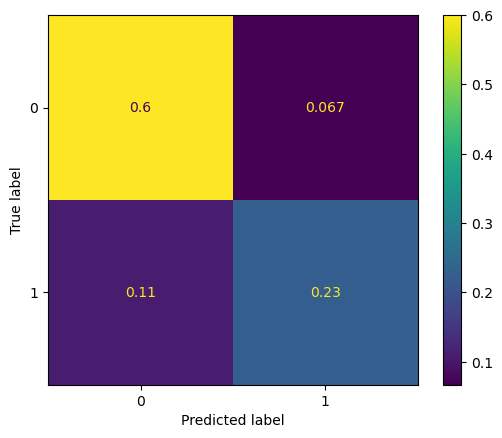

In [100]:
ConfusionMatrixDisplay.from_estimator(grid_model, scaled_x_test, y_test, normalize='all');

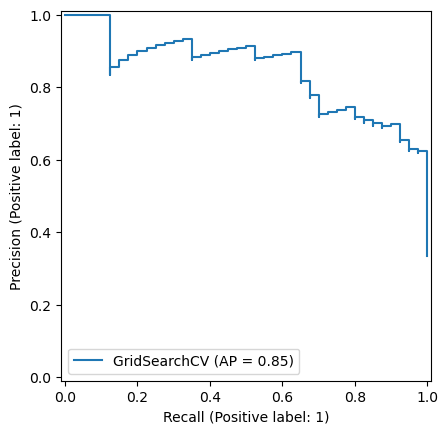

In [101]:
PrecisionRecallDisplay.from_estimator(grid_model,scaled_x_test, y_test);

```
The model is good in predicting the 0 values but weak in predicting 1 values, therefore we apply more complex technique 
to achieve a better results

# Let's go through another technique

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [118]:
df = pd.read_csv('Social_Network_Ads.csv')
df.sample(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
38,15671766,Female,26,72000,0
79,15655123,Female,26,17000,0
321,15611191,Female,53,82000,1
367,15671249,Male,46,88000,1
200,15628523,Male,35,39000,0


In [119]:
df = df.drop('User ID', axis=1)

In [120]:
X = df.drop('Purchased', axis=1)
y = df['Purchased']

In [121]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [124]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score, 
                            average_precision_score, classification_report, 
                            ConfusionMatrixDisplay, confusion_matrix)


In [126]:
num_feature = ['Age','EstimatedSalary']
cat_feature = ['Gender']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_feature),
    ('cat', OneHotEncoder(drop='first'), cat_feature)
])


pipe = Pipeline(steps=[
    ('preprocess',preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])


In [130]:
import warnings
warnings.filterwarnings('ignore')


param_grid = [
    {
        'clf__solver':['liblinear'],
        'clf__penalty': ['l1','l2'],
        'clf__C':[0.001,0.01,0.1,1,10,100],
        'clf__class_weight':[None, 'balanced']
    },
    {
        "clf__solver": ["saga"],
        "clf__penalty": ["elasticnet"],
        "clf__l1_ratio": [0.1, 0.5, 0.9],
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__class_weight": [None, "balanced"],
    }
]

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

grid = GridSearchCV(pipe, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1)
grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Age',
                                                                          'EstimatedSalary']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['Gender'])])),
                                       ('clf',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid=[{'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
                          'clf__class_weight': [None, 'balanced'],
                          'clf__penalty': ['l1', 'l2'],
                          'clf__solver': ['liblinear']},
                         {'clf__C': [0.01, 0.1, 1, 10],
                          'clf__class_weight': [None, 'balanced'],
                          'clf__l1_ratio': [0.1, 0.5, 0.9],
                          'clf__penalty': ['elasticnet'],
                          'clf__solver': ['saga']}],
             scoring='roc_auc')

In [131]:
final_model = grid.best_estimator_

In [132]:
preds = final_model.predict(X_test)

In [133]:
preds

array([0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0])

In [134]:
confusion_matrix(y_test, preds)

array([[79,  1],
       [20, 32]])

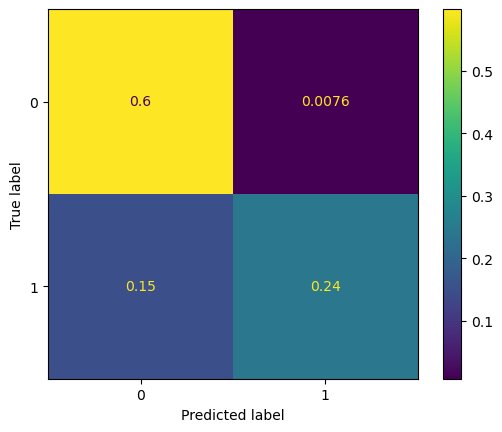

In [136]:
ConfusionMatrixDisplay.from_estimator(final_model,X_test, y_test, normalize='all' )

In [135]:
print(classification_report(y_test,preds))

              precision    recall  f1-score   support

           0       0.80      0.99      0.88        80
           1       0.97      0.62      0.75        52

    accuracy                           0.84       132
   macro avg       0.88      0.80      0.82       132
weighted avg       0.87      0.84      0.83       132



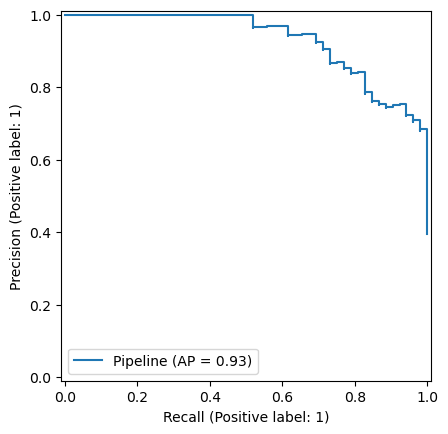

In [137]:
PrecisionRecallDisplay.from_estimator(final_model, X_test,y_test)

```
We have done pretty good prediction on 0 but still the error increase on 1 prediction

## Let's apply Polynomial technique

In [138]:
from sklearn.preprocessing import PolynomialFeatures

In [140]:
poly_preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scale', StandardScaler())
    ]), num_feature),
    ('cat', OneHotEncoder(drop='first'), cat_feature)
])

poly_pipe = Pipeline(steps=[
    ('perprocess', poly_preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

poly_grid = GridSearchCV(poly_pipe, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1)
poly_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('perprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('poly',
                                                                                          PolynomialFeatures(include_bias=False)),
                                                                                         ('scale',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'EstimatedSalary']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['Gender'])])),
                                       ('clf',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid=[{'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
                          'clf__class_weight': [None, 'balanced'],
                          'clf__penalty': ['l1', 'l2'],
                          'clf__solver': ['liblinear']},
                         {'clf__C': [0.01, 0.1, 1, 10],
                          'clf__class_weight': [None, 'balanced'],
                          'clf__l1_ratio': [0.1, 0.5, 0.9],
                          'clf__penalty': ['elasticnet'],
                          'clf__solver': ['saga']}],
             scoring='roc_auc')

In [142]:
poly_model = poly_grid.best_estimator_

In [143]:
new_pred = poly_model.predict(X_test)

In [144]:
confusion_matrix(y_test, new_pred)

array([[76,  4],
       [ 6, 46]])

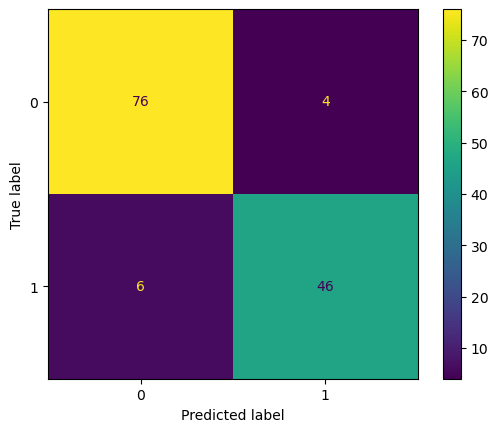

In [147]:
ConfusionMatrixDisplay.from_estimator(poly_model, X_test, y_test);

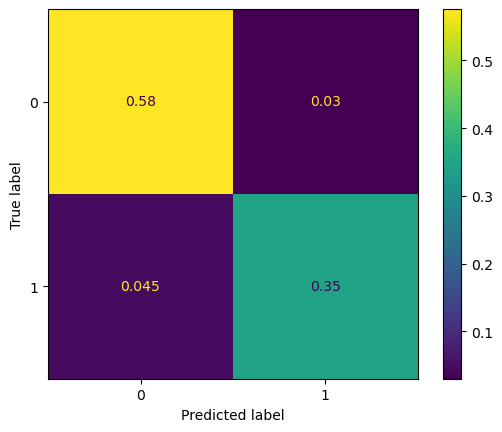

In [148]:
ConfusionMatrixDisplay.from_estimator(poly_model, X_test, y_test, normalize='all');

In [149]:
print(classification_report(y_test, new_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        80
           1       0.92      0.88      0.90        52

    accuracy                           0.92       132
   macro avg       0.92      0.92      0.92       132
weighted avg       0.92      0.92      0.92       132



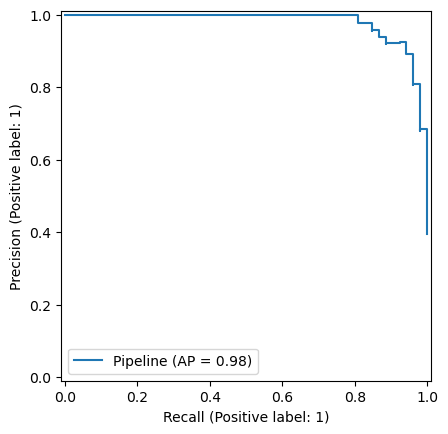

In [150]:
PrecisionRecallDisplay.from_estimator(poly_model, X_test, y_test)

In [151]:
print(accuracy_score(y_test, new_pred))

0.9242424242424242


```
The accuracy increased from 84% to 92% and thats's a good result

```
We test the model on random user and see how good it was fitted to our data

In [156]:
df.iloc[66]

Gender              Male
Age                   24
EstimatedSalary    19000
Purchased              0
Name: 66, dtype: object

In [169]:
new_user = pd.DataFrame([{
    'Gender': 'Male',
    'Age': 24,
    'EstimatedSalary': 19000
}])

In [170]:
poly_model.predict_proba(new_user) # 99% the output belong to 0 and the other 0.04% belongs to 1

array([[9.99566762e-01, 4.33238066e-04]])

In [171]:
poly_model.predict(new_user)

array([0])

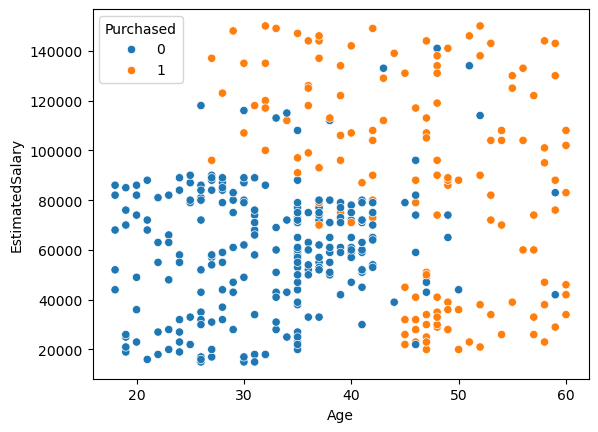

In [175]:
sns.scatterplot(df, x='Age', y='EstimatedSalary', hue='Purchased');

In [189]:
new_user = pd.DataFrame([{
    'Gender':'Male',
    'Age':19,
    'EstimatedSalary':80000
}])

In [190]:
poly_model.predict_proba(new_user) 

array([[0.99085506, 0.00914494]])

In [191]:
poly_model.predict(new_user)

array([0])

In [203]:
df[(df['Age'] == 48) & (df['Gender']== 'Male')]

,Gender,Age,EstimatedSalary,Purchased
22,Male,48,41000,1
264,Male,48,90000,1
284,Male,48,141000,0
301,Male,48,74000,1
381,Male,48,33000,1
390,Male,48,33000,1


# Linear vs Polynomail results

In [204]:
# For Polynomial

accuracy_score(y_test, new_pred)

0.9242424242424242

In [206]:
# For Linear

accuracy_score(y_test, preds)

0.8409090909090909

# Good Job